In [1]:
# Ví dụ 5: Vaccine cúm (X) và vaccine Covid-19 (Y)

# Danh sách các loại vaccine
X = ["Vaxigrip", "Fluarix", "Afluria", "Fluad"]  # x1, x2, x3, x4
Y = ["Pfizer", "Moderna", "AstraZeneca", "Sputnik",
     "Johnson&Johnson", "Sinovac"]              # y1..y6

# Tập mờ A, B (mức độ "tốt cho người trẻ")
# A = {1/x1, 1/x2, 0.8/x3, 0/x4}
# B = {1/y1, 1/y2, 0.8/y3, 0.5/y4, 0.6/y5, 0/y6}
mu_A = [1.0, 1.0, 0.8, 0.0]
mu_B = [1.0, 1.0, 0.8, 0.5, 0.6, 0.0]

# ------------------------------------------
# 1. Tính tích Descartes mờ C = A × B
#    mu_C(x_i, y_j) = min(mu_A[i], mu_B[j])
# ------------------------------------------
import numpy as np

A = np.array(mu_A)
B = np.array(mu_B)

# C là ma trận 4x6: hàng = vaccine cúm, cột = vaccine Covid-19
C = np.minimum(A[:, None], B[None, :])

print("Ma trận mức độ thuộc của C = A × B:")
print("Hàng:  X (cúm)  =", X)
print("Cột :  Y (Covid)=", Y)
print(np.round(C, 2))   # in làm tròn cho đẹp

# ------------------------------------------
# 2. In ra dưới dạng tập mờ C = { mu/(xi,yj), ... }
# ------------------------------------------
print("\nDạng tập mờ (mu / (xi, yj)):")

for i, vx in enumerate(X):
    for j, vy in enumerate(Y):
        mu = C[i, j]
        # giống slide: nếu muốn bỏ các phần tử có độ thuộc = 0 thì bỏ if
        print(f"{mu:.1f} / ({vx}, {vy})")

# ------------------------------------------
# 3. Tìm các cặp vaccine tốt nhất (mức độ lớn nhất)
# ------------------------------------------
max_mu = C.max()
best_pairs = np.argwhere(C == max_mu)

print("\nMức độ tốt nhất =", max_mu)
print("Các cặp vaccine (cúm, Covid-19) tốt nhất:")
for i, j in best_pairs:
    print(f"- ({X[i]}, {Y[j]}) với độ thuộc {C[i, j]:.1f}")


Ma trận mức độ thuộc của C = A × B:
Hàng:  X (cúm)  = ['Vaxigrip', 'Fluarix', 'Afluria', 'Fluad']
Cột :  Y (Covid)= ['Pfizer', 'Moderna', 'AstraZeneca', 'Sputnik', 'Johnson&Johnson', 'Sinovac']
[[1.  1.  0.8 0.5 0.6 0. ]
 [1.  1.  0.8 0.5 0.6 0. ]
 [0.8 0.8 0.8 0.5 0.6 0. ]
 [0.  0.  0.  0.  0.  0. ]]

Dạng tập mờ (mu / (xi, yj)):
1.0 / (Vaxigrip, Pfizer)
1.0 / (Vaxigrip, Moderna)
0.8 / (Vaxigrip, AstraZeneca)
0.5 / (Vaxigrip, Sputnik)
0.6 / (Vaxigrip, Johnson&Johnson)
0.0 / (Vaxigrip, Sinovac)
1.0 / (Fluarix, Pfizer)
1.0 / (Fluarix, Moderna)
0.8 / (Fluarix, AstraZeneca)
0.5 / (Fluarix, Sputnik)
0.6 / (Fluarix, Johnson&Johnson)
0.0 / (Fluarix, Sinovac)
0.8 / (Afluria, Pfizer)
0.8 / (Afluria, Moderna)
0.8 / (Afluria, AstraZeneca)
0.5 / (Afluria, Sputnik)
0.6 / (Afluria, Johnson&Johnson)
0.0 / (Afluria, Sinovac)
0.0 / (Fluad, Pfizer)
0.0 / (Fluad, Moderna)
0.0 / (Fluad, AstraZeneca)
0.0 / (Fluad, Sputnik)
0.0 / (Fluad, Johnson&Johnson)
0.0 / (Fluad, Sinovac)

Mức độ tốt nhất = 1.0
Các cặ

Ma trận C = A × B:
[[1.  1.  0.8 0.5 0.6 0. ]
 [1.  1.  0.8 0.5 0.6 0. ]
 [0.8 0.8 0.8 0.5 0.6 0. ]
 [0.  0.  0.  0.  0.  0. ]]


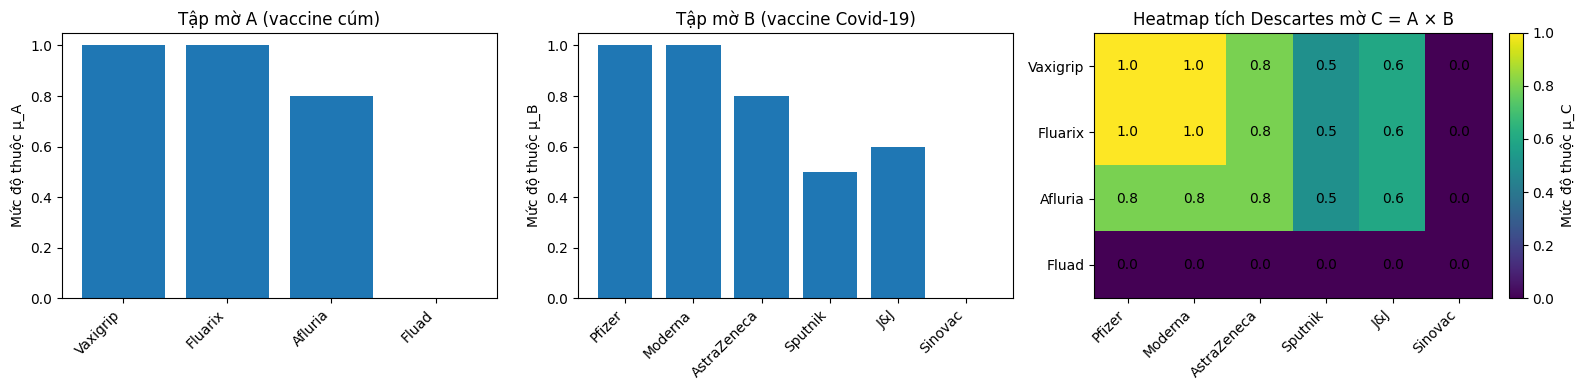

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Khai báo tập mờ A, B
# =========================
X = ["Vaxigrip", "Fluarix", "Afluria", "Fluad"]  # x1..x4
Y = ["Pfizer", "Moderna", "AstraZeneca", "Sputnik", "J&J", "Sinovac"]  # y1..y6

mu_A = np.array([1.0, 1.0, 0.8, 0.0])          # A = {1/x1, 1/x2, 0.8/x3, 0/x4}
mu_B = np.array([1.0, 1.0, 0.8, 0.5, 0.6, 0.0]) # B = {1/y1, 1/y2, 0.8/y3, 0.5/y4, 0.6/y5, 0/y6}

# =========================
# 2. Tính tích Descartes mờ C = A × B
#    mu_C(x_i, y_j) = min(mu_A[i], mu_B[j])
# =========================
C = np.minimum(mu_A[:, None], mu_B[None, :])    # ma trận 4x6

print("Ma trận C = A × B:")
print(np.round(C, 2))

# =========================
# 3. Vẽ hình minh họa
# =========================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- 3.1. Cột tập mờ A ---
axes[0].bar(range(len(X)), mu_A)
axes[0].set_xticks(range(len(X)))
axes[0].set_xticklabels(X, rotation=45, ha='right')
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Tập mờ A (vaccine cúm)")
axes[0].set_ylabel("Mức độ thuộc μ_A")

# --- 3.2. Cột tập mờ B ---
axes[1].bar(range(len(Y)), mu_B)
axes[1].set_xticks(range(len(Y)))
axes[1].set_xticklabels(Y, rotation=45, ha='right')
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Tập mờ B (vaccine Covid-19)")
axes[1].set_ylabel("Mức độ thuộc μ_B")

# --- 3.3. Heatmap C = A × B ---
im = axes[2].imshow(C, vmin=0, vmax=1)

axes[2].set_xticks(range(len(Y)))
axes[2].set_xticklabels(Y, rotation=45, ha='right')
axes[2].set_yticks(range(len(X)))
axes[2].set_yticklabels(X)
axes[2].set_title("Heatmap tích Descartes mờ C = A × B")

# Ghi giá trị μ lên từng ô
for i in range(len(X)):
    for j in range(len(Y)):
        axes[2].text(j, i, f"{C[i, j]:.1f}", ha='center', va='center')

# Thanh màu (colorbar) cho heatmap
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04, label="Mức độ thuộc μ_C")

plt.tight_layout()
plt.show()


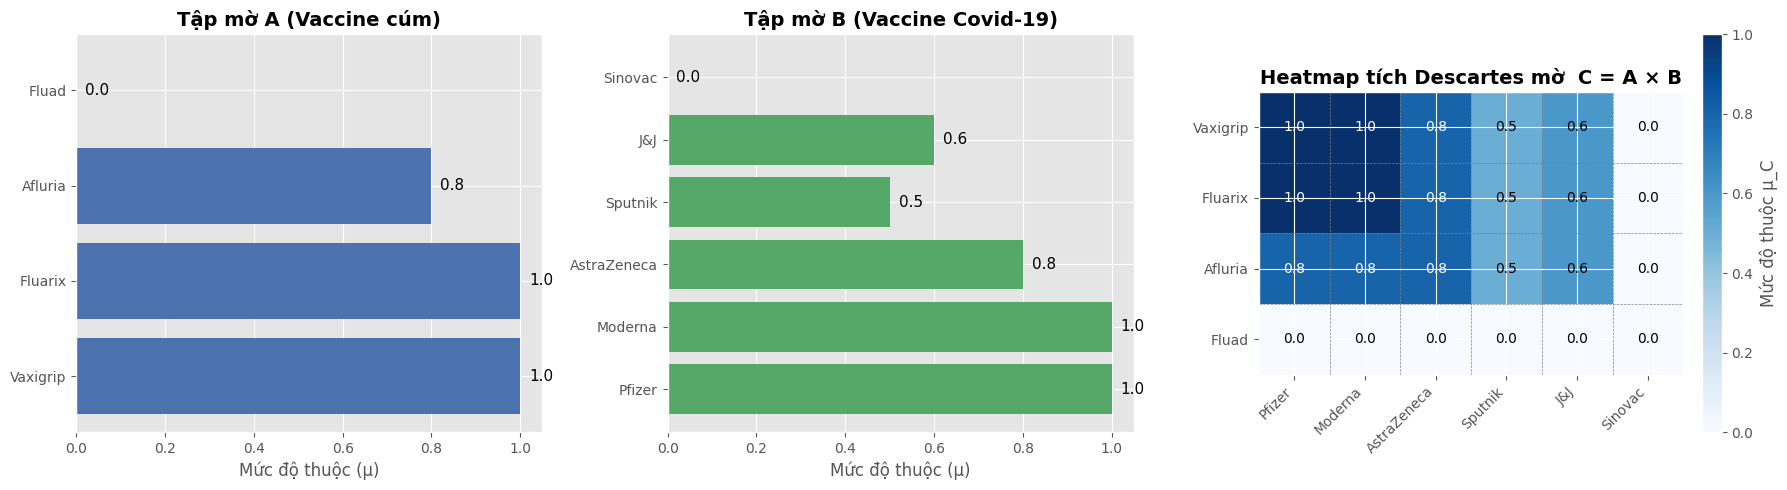

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# =====================================
# 1. Dữ liệu
# =====================================
X = ["Vaxigrip", "Fluarix", "Afluria", "Fluad"]
Y = ["Pfizer", "Moderna", "AstraZeneca", "Sputnik", "J&J", "Sinovac"]

mu_A = np.array([1.0, 1.0, 0.8, 0.0])
mu_B = np.array([1.0, 1.0, 0.8, 0.5, 0.6, 0.0])

C = np.minimum(mu_A[:, None], mu_B[None, :])

# =====================================
# 2. Style đẹp
# =====================================
plt.style.use("ggplot")

# FIX: dùng cm.Blues thay cho cm.get_cmap
cmap = cm.Blues

# =====================================
# 3. Vẽ 3 biểu đồ
# =====================================
fig = plt.figure(figsize=(18, 5))

# ----------------------------------------------------
# Biểu đồ 1: A – vaccine cúm
# ----------------------------------------------------
ax1 = fig.add_subplot(1, 3, 1)
bars = ax1.barh(X, mu_A, color="#4C72B0")
ax1.set_xlim(0, 1.05)
ax1.set_title("Tập mờ A (Vaccine cúm)", fontsize=14, fontweight="bold")
ax1.set_xlabel("Mức độ thuộc (μ)")
for bar in bars:
    ax1.text(bar.get_width() + 0.02,
             bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.1f}", va="center", fontsize=11)

# ----------------------------------------------------
# Biểu đồ 2: B – vaccine Covid-19
# ----------------------------------------------------
ax2 = fig.add_subplot(1, 3, 2)
bars = ax2.barh(Y, mu_B, color="#55A868")
ax2.set_xlim(0, 1.05)
ax2.set_title("Tập mờ B (Vaccine Covid-19)", fontsize=14, fontweight="bold")
ax2.set_xlabel("Mức độ thuộc (μ)")
for bar in bars:
    ax2.text(bar.get_width() + 0.02,
             bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.1f}", va="center", fontsize=11)

# ----------------------------------------------------
# Biểu đồ 3: Heatmap C = A × B
# ----------------------------------------------------
ax3 = fig.add_subplot(1, 3, 3)
im = ax3.imshow(C, cmap=cmap, vmin=0, vmax=1)

ax3.set_xticks(range(len(Y)))
ax3.set_yticks(range(len(X)))
ax3.set_xticklabels(Y, rotation=45, ha="right", fontsize=10)
ax3.set_yticklabels(X, fontsize=10)

ax3.set_title("Heatmap tích Descartes mờ  C = A × B",
              fontsize=14, fontweight="bold")

# Ghi số lên từng ô
for i in range(len(X)):
    for j in range(len(Y)):
        value = C[i, j]
        ax3.text(j, i, f"{value:.1f}", ha="center", va="center",
                 color="white" if value > 0.6 else "black")

# Lưới
ax3.set_xticks(np.arange(-.5, len(Y), 1), minor=True)
ax3.set_yticks(np.arange(-.5, len(X), 1), minor=True)
ax3.grid(which='minor', color='gray', linestyle='--', linewidth=0.5)
ax3.tick_params(which="minor", bottom=False, left=False)

# Colorbar
cbar = plt.colorbar(im, ax=ax3, fraction=0.05, pad=0.04)
cbar.set_label("Mức độ thuộc μ_C", rotation=90)

plt.tight_layout()
plt.show()
